# Perform unfolding on EEG data from Stop-signal task with RidgeCV

In [1]:
import pickle
import warnings
import os

import mne
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from himalaya.ridge import RidgeCV

# sys.path.insert(1, '../')
from basic_unfold_model import UnfoldModelPy
from models import models

import unfold_model

# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Projects/neuroNoodle/unfold`


Status `~/Projects/neuroNoodle/unfold/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
Precompiling project...
  ✓ NNlib → NNlibForwardDiffExt
  ✓ MLUtils
  ✓ StatisticalMeasuresBase
  ✓ MLJEnsembles
  ✓ MLJBase
  ✓ StatisticalMeasures
  ✓ StatisticalMeasures → ScientificTypesExt
  ✓ MLJBase → DefaultMeasuresExt
  ✓ MLJFlow
  ✓ MLJTuning
  ✓ MLJBalancing
  ✓ MLJIteration
  ✓ MLJ
  ✓ UnfoldDecode
  14 dependencies successfully precompiled in 24 seconds. 216 already precompiled.
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
[ Info: Precompiling UnfoldDecode [ec0f67a1-ae9f-4687-b20b-bd39d

Status `~/Projects/neuroNoodle/unfold/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
Precompiling project...
  ✓ NNlib → NNlibFFTWExt
  1 dependency successfully precompiled in 5 seconds. 229 already precompiled.
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
  Activating project at `~/Projects/neuroNoodle/unfold`
   Resolving package versions...


Status `~/Projects/neuroNoodle/unfold/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`


Define picks

In [2]:
picks = [
    'Fp1',
    'AF3',
    'F7',
    'F3',
    'FC1',
    'FC5',
    'T7',
    'C3',
    'CP1',
    'CP5',
    'P7',
    'P3',
    'Pz',
    'PO3',
    'O1',
    'Oz',
    'O2',
    'PO4',
    'P4',
    'P8',
    'CP6',
    'CP2',
    'C4',
    'T8',
    'FC6',
    'FC2',
    'F4',
    'F8',
    'AF4',
    'Fp2',
    'Fz',
    'Cz',
]

## Read events and EEG data

In [3]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


## Perform RidgeCV unfolding

In [5]:
current_unfold_model = models.get_full_model()

In [ ]:
for file_name in file_names[:1]:
    try:
        # read events dict
        with open(f'{events_data_dir}/{file_name}.pickle', 'rb') as handle:
            events = pickle.load(handle) # events dict channel_name:events_df
    
        # read EEG
        raw = mne.io.read_raw_brainvision(
            f'{eeg_data_dir}/{file_name}.vhdr',
            preload=True,
            eog=('HEOG', 'VEOG'),
        ).pick(picks=picks)
    
        # perform unfolding separately for each channel
        # channels = raw.info['ch_names']
        channels = ['Fz']
        results_channels = dict()
        for channel in channels:
            channel_events_df = events[channel]
            # clear bad segments
            channel_events_df = channel_events_df[channel_events_df['bad'] == False]
            # get EEG data
            eeg_data = raw.get_data(picks=channel)
            # cast EEG data from V to uV
            eeg_data = eeg_data * 1000000
            
            model = UnfoldModelPy(
                u_model = current_unfold_model,
            )
            model.fit(eeg_data, channel_events_df)
            predicted_raw_train = model.predict(signal=eeg_data, events_df=channel_events_df)

            results_channel_df = model.get_results(predicted=True, signal=eeg_data, events_df=channel_events_df)

    except Exception as e:
        print(e)

In [12]:
predicted_signal = results_channel_df[results_channel_df['coefname'] == 'predicted']['estimate'].to_numpy().flatten()
original_signal = results_channel_df[results_channel_df['coefname'] == 'original']['estimate'].to_numpy().flatten()

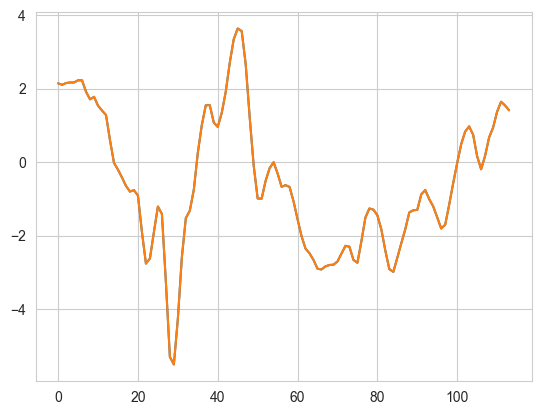

In [14]:
plt.plot(original_signal, label='original')
plt.plot(predicted_signal, label='predicted')

In [17]:
model.coeftable

,channel,coefname,estimate,eventname,group,stderror,time
0,1,baseline,0.976757,baseline,None,None,0.000000
1,1,baseline,0.968095,baseline,None,None,0.015625
2,1,baseline,0.942067,baseline,None,None,0.031250
3,1,baseline,0.922031,baseline,None,None,0.046875
4,1,baseline,0.917117,baseline,None,None,0.062500
...,...,...,...,...,...,...,...
348,1,(Intercept),-0.281629,response_nostop,None,None,0.531250
349,1,(Intercept),0.081020,response_nostop,None,None,0.546875
350,1,(Intercept),0.400354,response_nostop,None,None,0.562500
351,1,(Intercept),0.179445,response_nostop,None,None,0.578125
